<a href="https://colab.research.google.com/github/sirimadhuri02/CognitiveScienceAndAnalytics/blob/GaborFilter/Gabor2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import pandas as pd
import os

In [ ]:
def create_pattern(size=128, pattern_type='checkerboard', **kwargs):
    """
    Creates 2D grayscale patterns to be used as stimuli.
    Available patterns:
      - 'checkerboard'
      - 'rotated_grating'
      - 'vertical_stripe'
      - 'horizontal_stripe'
      - 'random_noise'
    """
    img = np.zeros((size, size), dtype=float)

    if pattern_type == 'checkerboard':
        num_squares = kwargs.get('num_squares', 8)
        square_size = size // num_squares
        for y in range(size):
            for x in range(size):
                if ((x // square_size) + (y // square_size)) % 2 == 0:
                    img[y, x] = 1.0

    elif pattern_type == 'rotated_grating':
        freq = kwargs.get('freq', 6)
        angle = kwargs.get('angle', np.pi/6)  # default 30 degrees
        x = np.linspace(-np.pi, np.pi, size)
        X, Y = np.meshgrid(x, x)
        Xr = X * np.cos(angle) + Y * np.sin(angle)
        img = 0.5 + 0.5 * np.sin(freq * Xr)

    elif pattern_type == 'vertical_stripe':
        thickness = kwargs.get('thickness', 16)
        center = size // 2
        img[:, center - thickness//2 : center + thickness//2] = 1.0

    elif pattern_type == 'horizontal_stripe':
        thickness = kwargs.get('thickness', 16)
        center = size // 2
        img[center - thickness//2 : center + thickness//2, :] = 1.0

    elif pattern_type == 'random_noise':
        noise_level = kwargs.get('noise_level', 0.5)
        img = np.random.rand(size, size) * noise_level
        img = (img - img.min()) / (img.max() - img.min())

    else:
        raise ValueError("Unknown pattern type.")

    return img

In [ ]:
def make_gabor(size=64, orientation=0.0, freq=0.1, sigma=8.0, phase=0.0):
    """
    Generates a Gabor filter kernel.
    """
    ax = np.linspace(-size//2, size//2, size)
    X, Y = np.meshgrid(ax, ax)
    X_rot = X * np.cos(orientation) + Y * np.sin(orientation)
    gauss = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    wave = np.cos(2 * np.pi * freq * X_rot + phase)
    gabor = gauss * wave
    gabor -= np.mean(gabor)
    return gabor


In [ ]:
def filter_response(stimulus, gabor_filter):
    """
    Convolves stimulus with Gabor filter.
    """
    return convolve2d(stimulus, gabor_filter, mode='same', boundary='symm')

In [ ]:
patterns = [
    ('checkerboard', {'num_squares': 8}),
    ('rotated_grating', {'freq': 5, 'angle': np.pi/4}),
    ('vertical_stripe', {'thickness': 14}),
    ('horizontal_stripe', {'thickness': 14}),
    ('random_noise', {'noise_level': 0.8})
]

gabors = [
    {'orientation': 0.0, 'freq': 0.08, 'sigma': 6.0},
    {'orientation': np.pi/2, 'freq': 0.08, 'sigma': 6.0},
    {'orientation': np.pi/4, 'freq': 0.12, 'sigma': 7.0}
]

out_folder = "outputs_visual_auditory"
os.makedirs(out_folder, exist_ok=True)
visual_results = []


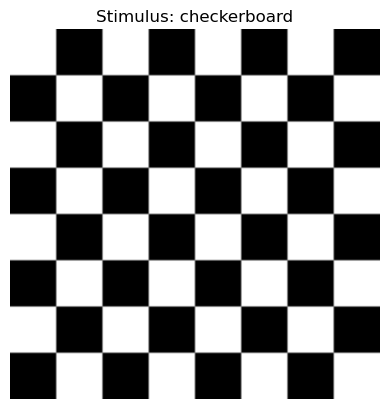

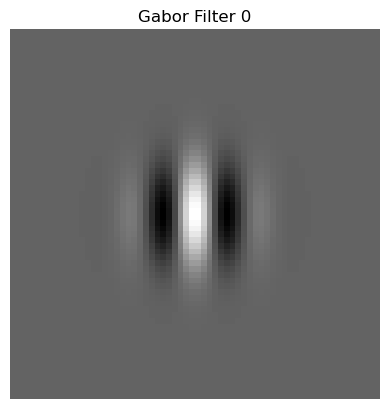

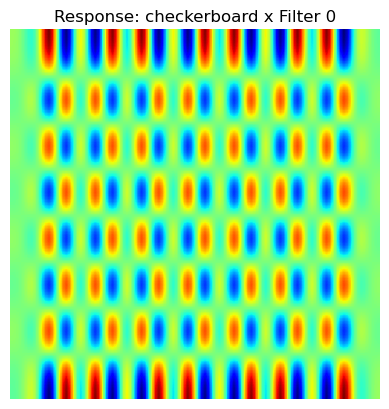

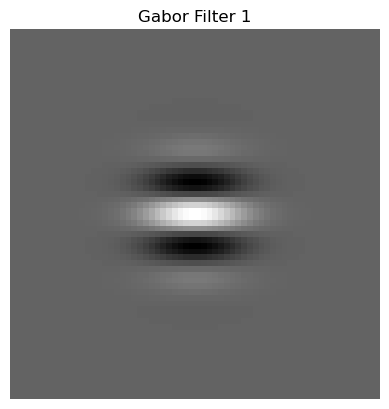

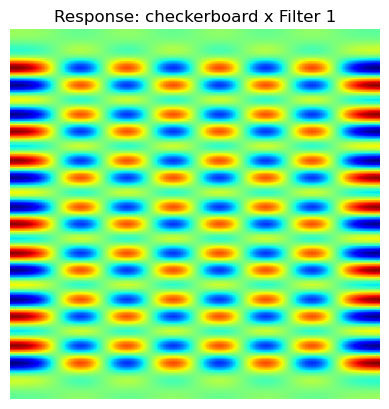

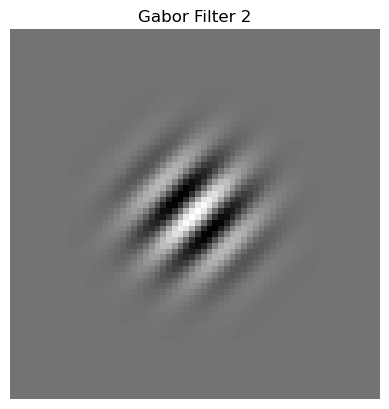

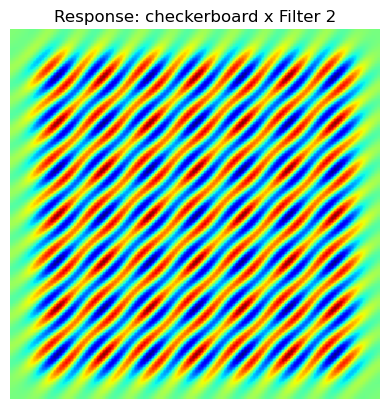

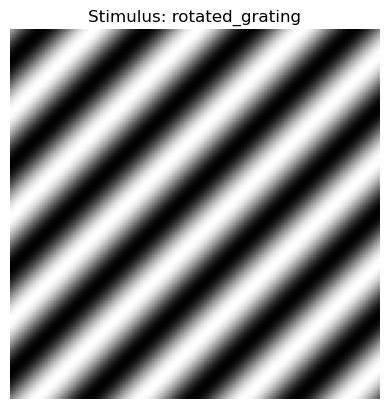

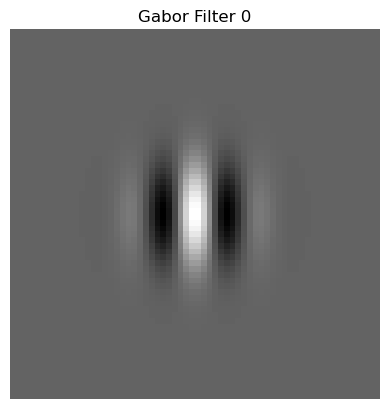

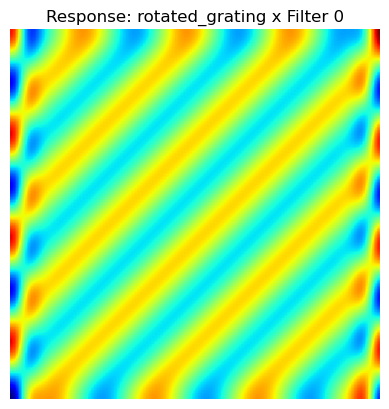

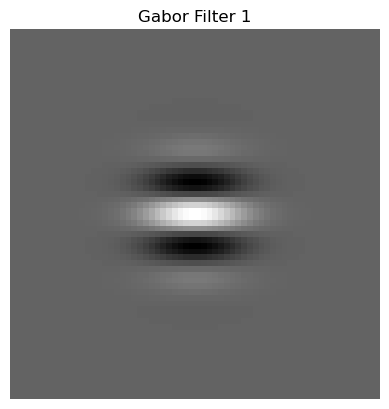

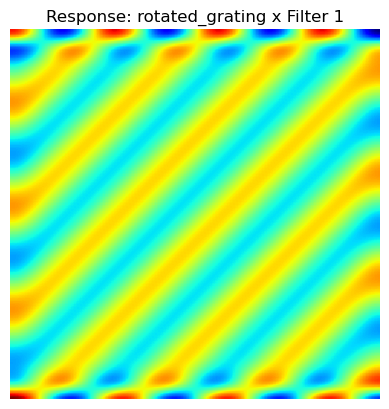

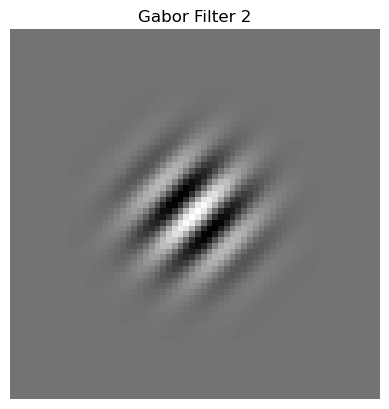

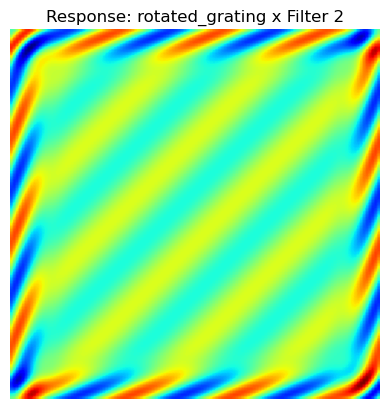

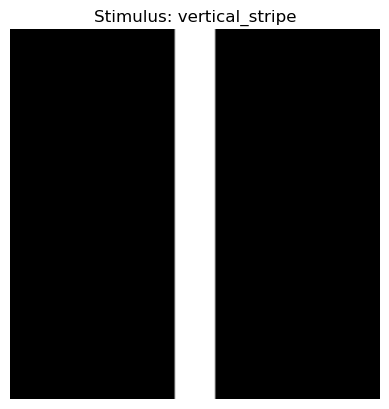

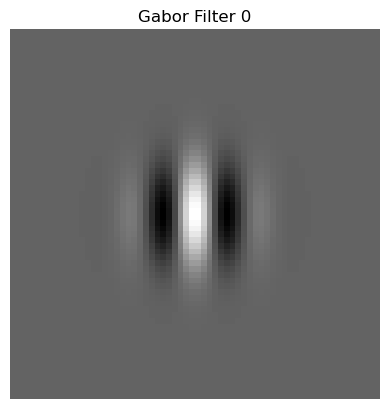

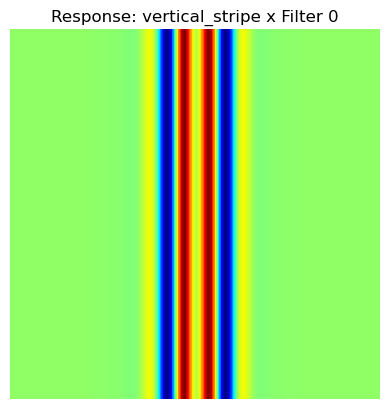

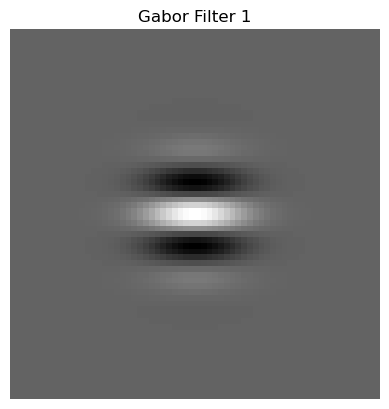

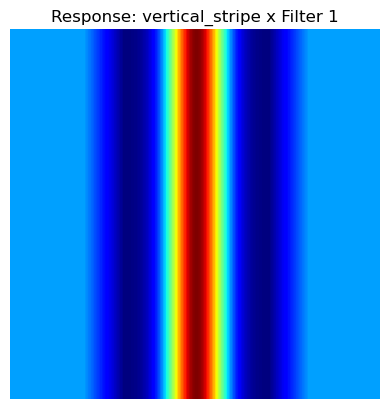

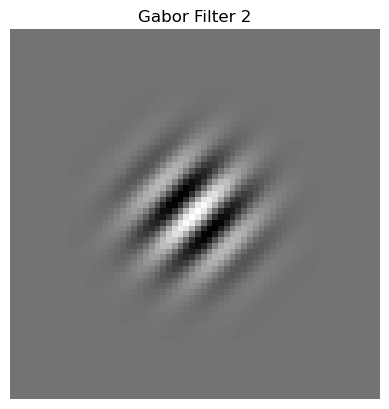

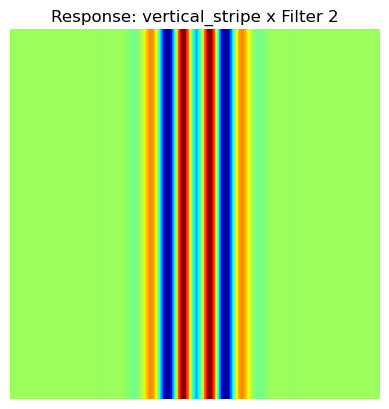

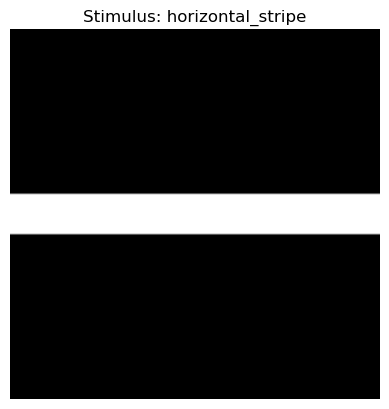

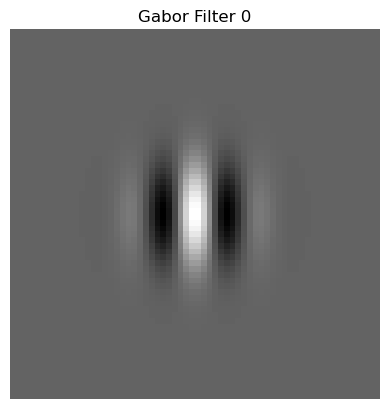

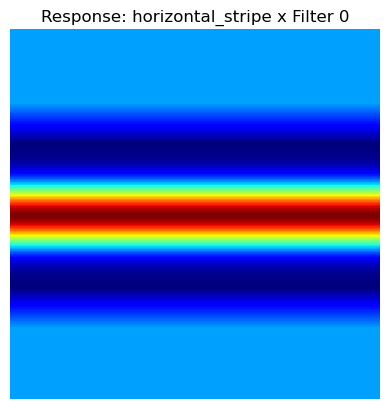

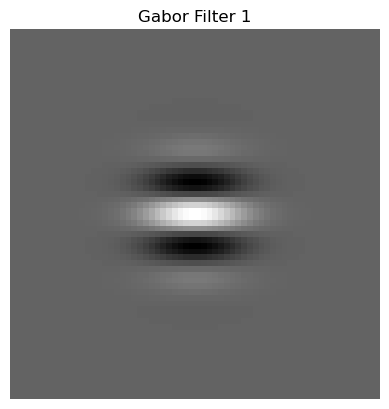

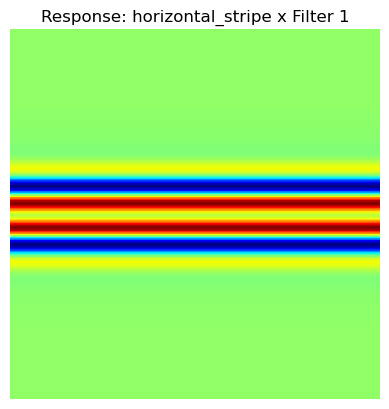

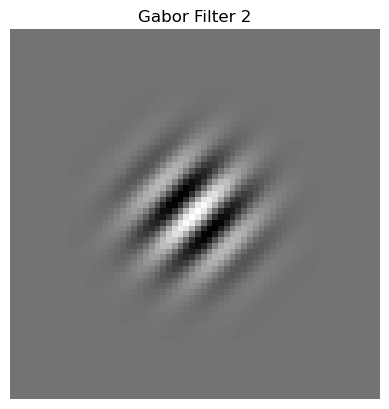

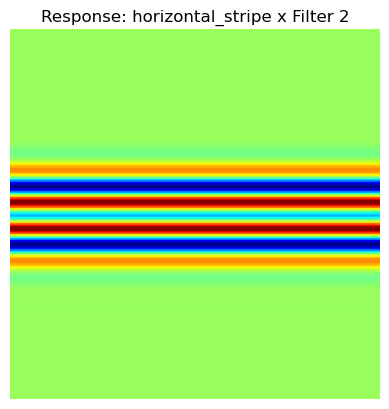

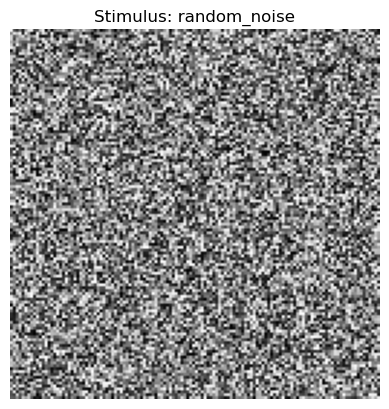

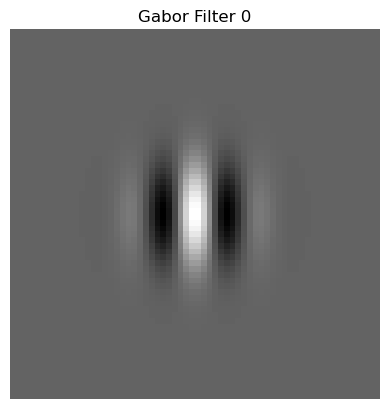

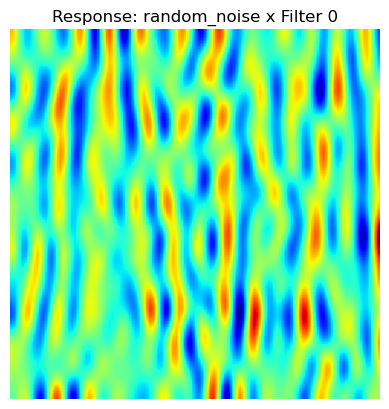

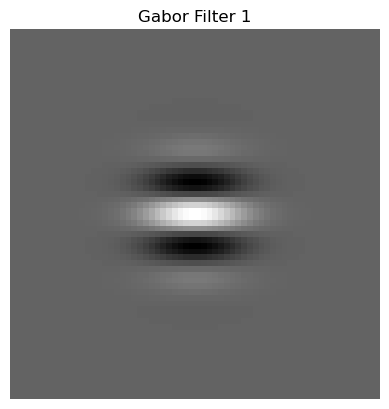

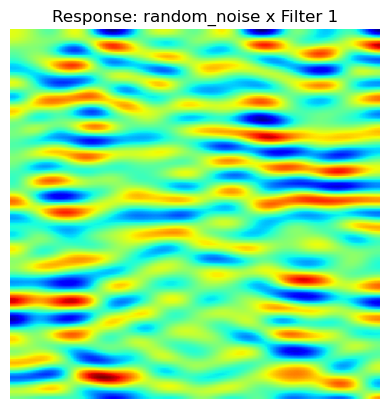

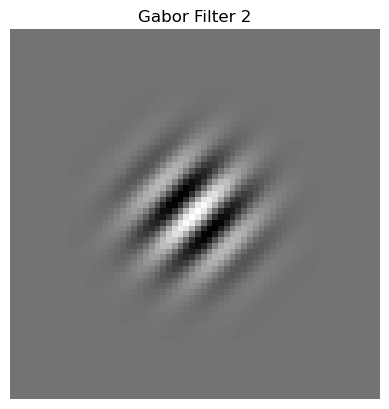

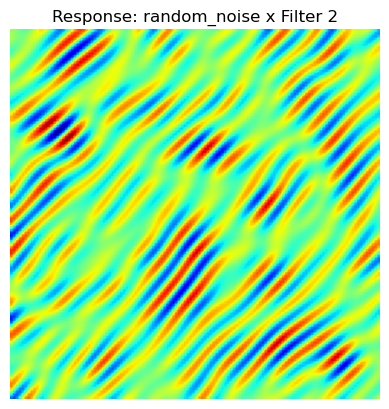

In [ ]:
for p_name, p_params in patterns:
    stim = create_pattern(128, p_name, **p_params)
    plt.imshow(stim, cmap='gray')
    plt.title(f"Stimulus: {p_name}")
    plt.axis('off')
    plt.savefig(os.path.join(out_folder, f"stim_{p_name}.png"))
    plt.show()

    for idx, g_params in enumerate(gabors):
        gf = make_gabor(64, **g_params)
        plt.imshow(gf, cmap='gray')
        plt.title(f"Gabor Filter {idx}")
        plt.axis('off')
        plt.savefig(os.path.join(out_folder, f"gabor_{idx}.png"))
        plt.show()

        resp = filter_response(stim, gf)
        plt.imshow(resp, cmap='jet')
        plt.title(f"Response: {p_name} x Filter {idx}")
        plt.axis('off')
        plt.savefig(os.path.join(out_folder, f"response_{p_name}_f{idx}.png"))
        plt.show()

        visual_results.append({
            'stimulus': p_name,
            'filter_id': idx,
            'orientation_deg': np.degrees(g_params['orientation']),
            'frequency': g_params['freq'],
            'sigma': g_params['sigma'],
            'max_response': np.max(resp),
            'min_response': np.min(resp),
            'mean_response': np.mean(resp),
            'std_dev': np.std(resp),
            'range': np.max(resp) - np.min(resp)
        })

In [ ]:
df_visual = pd.DataFrame(visual_results)
df_visual.to_csv(os.path.join(out_folder, "visual_summary.csv"), index=False)
print("Visual summary saved.")

Visual summary saved.


In [ ]:
def generate_signal(frequency=5.0, duration=1.0, sample_rate=1000, noise_amp=0.3):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    signal = np.sin(2 * np.pi * frequency * t)
    noise = np.random.normal(0, noise_amp, len(t))
    return t, signal + noise

In [ ]:
def variable_threshold(signal, base_thresh=0.5, scaling=0.1):
    thresholds = base_thresh + scaling * np.sin(np.linspace(0, 2*np.pi, len(signal)))
    firing = signal > thresholds
    firing_rate = np.mean(firing)
    return firing.astype(int), firing_rate

In [ ]:
auditory_configs = [
    {'frequency': 5.0, 'noise_amp': 0.2, 'base_thresh': 0.4},
    {'frequency': 12.0, 'noise_amp': 0.5, 'base_thresh': 0.5},
    {'frequency': 18.0, 'noise_amp': 0.7, 'base_thresh': 0.3}
]

auditory_results = []

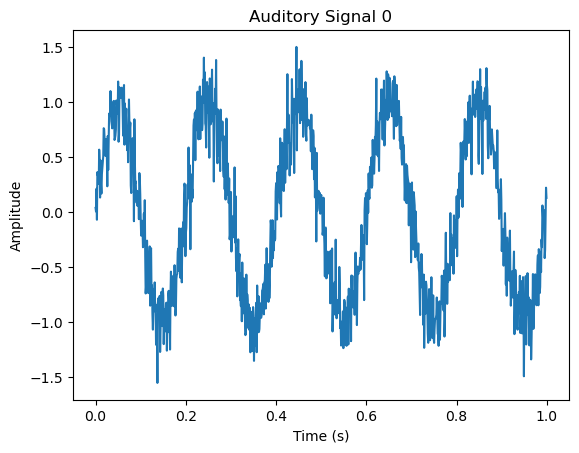

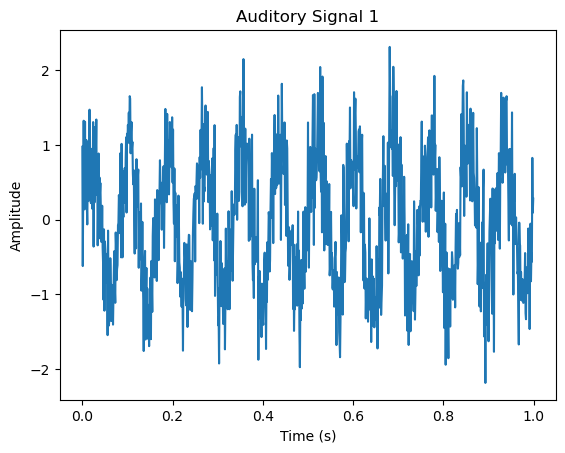

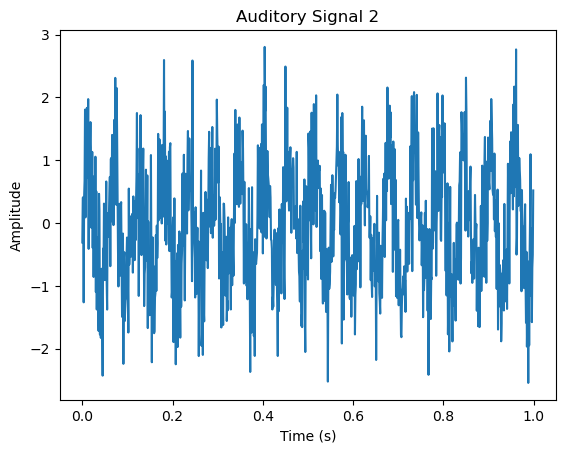

In [ ]:

for idx, cfg in enumerate(auditory_configs):
    t, sig = generate_signal(cfg['frequency'], noise_amp=cfg['noise_amp'])
    firing, rate = variable_threshold(sig, base_thresh=cfg['base_thresh'])

    plt.plot(t, sig)
    plt.title(f"Auditory Signal {idx}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.savefig(os.path.join(out_folder, f"aud_signal_{idx}.png"))
    plt.show()


In [ ]:
plt.plot(t, firing * np.max(sig))
    plt.title(f"Firing Pattern {idx}")
    plt.xlabel("Time (s)")
    plt.ylabel("Firing (scaled)")
    plt.savefig(os.path.join(out_folder, f"aud_firing_{idx}.png"))
    plt.show()

IndentationError: unexpected indent (3081565237.py, line 2)

In [ ]:
auditory_results.append({
        'signal_id': idx,
        'frequency': cfg['frequency'],
        'noise_amp': cfg['noise_amp'],
        'base_threshold': cfg['base_thresh'],
        'firing_fraction': rate,
        'signal_max': np.max(sig),
        'signal_min': np.min(sig)
    })

In [ ]:
df_auditory = pd.DataFrame(auditory_results)
df_auditory.to_csv(os.path.join(out_folder, "auditory_summary.csv"), index=False)
print("Auditory summary saved.")